# Regression Case Study — Subscription Revenue

## Predict continuous customer value with leakage-safe validation

This self-contained case study uses reproducible synthetic data. Every major step produces a result table and chart. The numbers illustrate a workflow and are not claims about real people or businesses.

In [1]:
from pathlib import Path
import json, warnings, joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563eb", "#059669", "#f59e0b", "#dc2626", "#64748b"]
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.options.display.float_format = "{:,.3f}".format

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

mkdir -p failed for path C:\Users\jacob\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jacob\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jacob\AppData\Local\Temp\matplotlib-cfvdxyax because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Define the regression contract

The target is a continuous amount: next-quarter customer revenue.

,item,definition,importance
0,Decision,Allocate account-management effort,5
1,Unit,One active subscriber,5
2,Target,Revenue in the next 90 days,5
3,Primary metric,MAE in dollars,4
4,Guardrails,Error by plan and region,4


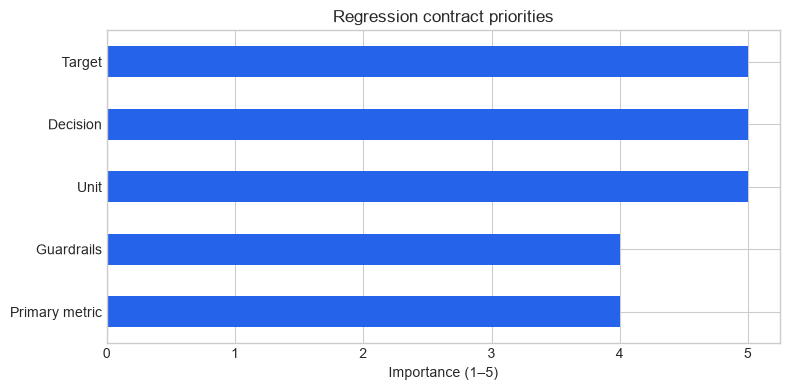

In [2]:
contract = pd.DataFrame([
    ("Decision", "Allocate account-management effort", 5),
    ("Unit", "One active subscriber", 5),
    ("Target", "Revenue in the next 90 days", 5),
    ("Primary metric", "MAE in dollars", 4),
    ("Guardrails", "Error by plan and region", 4),
], columns=["item", "definition", "importance"])
display(contract)
ax=contract.sort_values("importance").plot.barh(x="item",y="importance",legend=False,color=COLORS[0],figsize=(8,4))
ax.set(title="Regression contract priorities",xlabel="Importance (1–5)",ylabel=""); plt.tight_layout(); plt.show()

## 2. Generate and validate synthetic data

The target combines usage, tenure, plan, discounts, and noise; a small amount of missingness tests the pipeline.

,tenure_months,monthly_usage_hours,support_tickets,discount_pct,plan,region,next_90d_revenue
0,8,72.071,0,0,Premium,West,504.006
1,66,37.651,1,15,Plus,Central,495.953
2,55,1.000,1,15,Plus,West,233.489
3,37,18.428,0,10,Basic,West,102.346
4,37,79.011,1,10,Basic,West,449.212
5,73,44.376,4,20,Premium,Central,535.691
6,8,37.736,0,20,Plus,Central,281.374
7,59,83.211,1,10,Premium,East,853.080


,column,dtype,missing_n,missing_pct,unique
0,tenure_months,int64,0,0.000,84
1,monthly_usage_hours,float64,210,3.500,5764
2,support_tickets,int64,0,0.000,9
3,discount_pct,int64,0,0.000,5
4,plan,str,0,0.000,3
5,region,str,120,2.000,3
6,next_90d_revenue,float64,0,0.000,5990


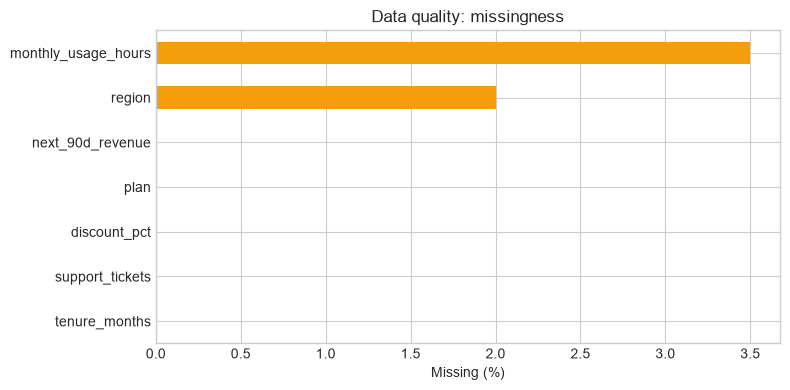

In [3]:
n=6000
df=pd.DataFrame({
    "tenure_months":rng.integers(1,85,n), "monthly_usage_hours":np.clip(rng.normal(52,19,n),1,140),
    "support_tickets":np.clip(rng.poisson(1.7,n),0,10), "discount_pct":rng.choice([0,5,10,15,20],n,p=[.35,.15,.25,.15,.10]),
    "plan":rng.choice(["Basic","Plus","Premium"],n,p=[.45,.35,.20]), "region":rng.choice(["West","Central","East"],n)
})
df["next_90d_revenue"]=(115+1.6*df.tenure_months+3.8*df.monthly_usage_hours-9*df.support_tickets-4.5*df.discount_pct
                         +df.plan.map({"Basic":0,"Plus":105,"Premium":260})+df.region.map({"West":30,"Central":0,"East":18})
                         +rng.normal(0,75,n)).clip(20)
for c,f in {"monthly_usage_hours":.035,"region":.02}.items(): df.loc[rng.choice(n,int(n*f),replace=False),c]=np.nan
quality=pd.DataFrame({"dtype":df.dtypes.astype(str),"missing_n":df.isna().sum(),"missing_pct":100*df.isna().mean(),"unique":df.nunique()}).reset_index(names="column")
display(df.head(8)); display(quality)
ax=quality.sort_values("missing_pct").plot.barh(x="column",y="missing_pct",legend=False,color=COLORS[2],figsize=(8,4))
ax.set(title="Data quality: missingness",xlabel="Missing (%)",ylabel=""); plt.tight_layout(); plt.show()

## 3. Explore the continuous target and segments

,customers,mean_revenue,median_revenue,std_revenue
plan,,,,
Basic,2698,351.749,351.905,115.381
Plus,2126,450.659,450.607,113.035
Premium,1176,598.061,597.127,114.046


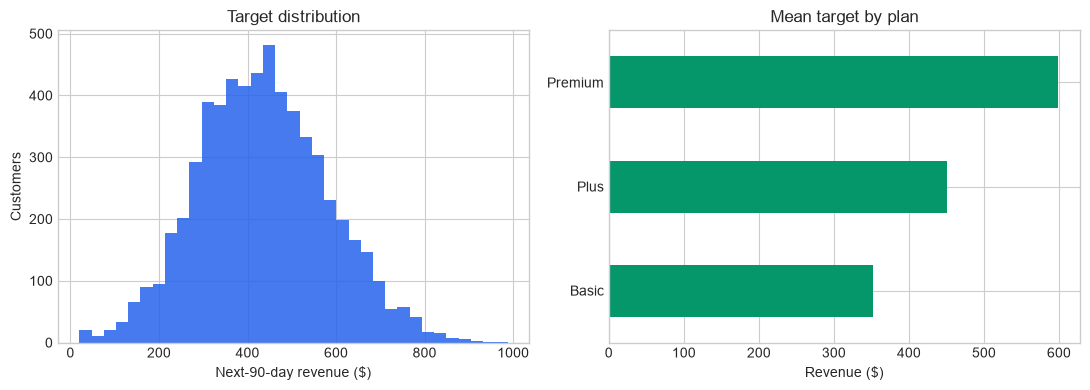

In [4]:
segments=df.groupby("plan",observed=True).agg(customers=("next_90d_revenue","size"),mean_revenue=("next_90d_revenue","mean"),median_revenue=("next_90d_revenue","median"),std_revenue=("next_90d_revenue","std")).sort_values("mean_revenue")
display(segments)
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].hist(df.next_90d_revenue,bins=35,color=COLORS[0],alpha=.85); axes[0].set(title="Target distribution",xlabel="Next-90-day revenue ($)",ylabel="Customers")
segments.mean_revenue.plot.barh(ax=axes[1],color=COLORS[1]); axes[1].set(title="Mean target by plan",xlabel="Revenue ($)",ylabel=""); plt.tight_layout(); plt.show()

## 4. Split first and construct the preprocessing pipeline

,rows,target_mean,target_std
train,4800,435.725,146.022
test,1200,432.467,148.640


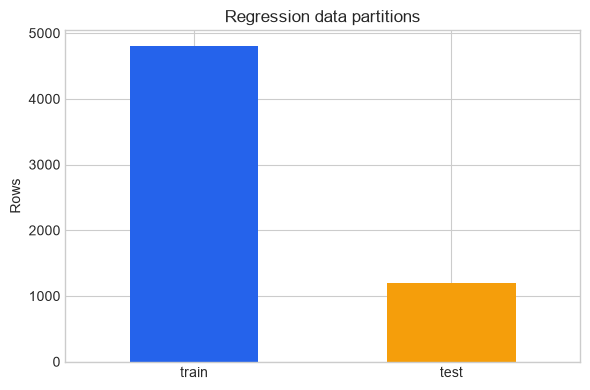

In [5]:
X=df.drop(columns="next_90d_revenue"); y=df.next_90d_revenue
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=RANDOM_STATE)
split=pd.DataFrame({"rows":[len(X_train),len(X_test)],"target_mean":[y_train.mean(),y_test.mean()],"target_std":[y_train.std(),y_test.std()]},index=["train","test"])
display(split)
ax=split.rows.plot.bar(rot=0,color=[COLORS[0],COLORS[2]],figsize=(6,4)); ax.set(title="Regression data partitions",ylabel="Rows",xlabel=""); plt.tight_layout(); plt.show()
num=X.select_dtypes(include="number").columns; cat=X.select_dtypes(exclude="number").columns
prep=ColumnTransformer([("num",Pipeline([("impute",SimpleImputer(strategy="median")),("scale",StandardScaler())]),num),
                        ("cat",Pipeline([("impute",SimpleImputer(strategy="most_frequent")),("encode",OneHotEncoder(handle_unknown="ignore"))]),cat)])

## 5. Compare a baseline and tune a nonlinear model

,model,test_mae
0,Median baseline,119.625
1,Tuned random forest,62.851


,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score,cv_mae
7,140,10,6,-62.967,1.733,1,62.967
6,80,10,6,-63.011,1.740,2,63.011
11,140,None,6,-63.081,1.659,3,63.081
10,80,None,6,-63.113,1.676,4,63.113
5,140,10,2,-63.391,1.669,5,63.391
4,80,10,2,-63.469,1.685,6,63.469
3,140,6,6,-64.251,1.550,7,64.251
1,140,6,2,-64.292,1.576,8,64.292


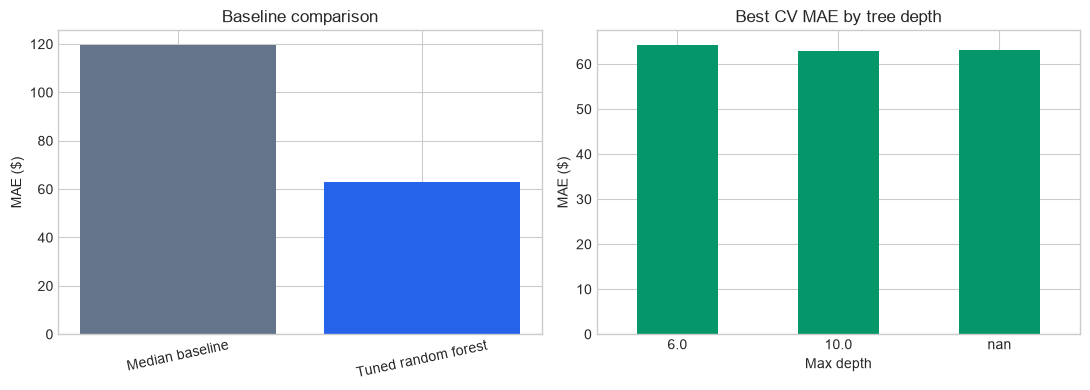

In [6]:
baseline=DummyRegressor(strategy="median").fit(X_train,y_train); base_pred=baseline.predict(X_test)
pipe=Pipeline([("prep",prep),("model",RandomForestRegressor(random_state=RANDOM_STATE,n_jobs=1))])
search=GridSearchCV(pipe,{"model__n_estimators":[80,140],"model__max_depth":[6,10,None],"model__min_samples_leaf":[2,6]},scoring="neg_mean_absolute_error",cv=4,n_jobs=1)
search.fit(X_train,y_train); pred=search.predict(X_test)
cv=pd.DataFrame(search.cv_results_)[["param_model__n_estimators","param_model__max_depth","param_model__min_samples_leaf","mean_test_score","std_test_score","rank_test_score"]]
cv["cv_mae"]=-cv.mean_test_score
comparison=pd.DataFrame({"model":["Median baseline","Tuned random forest"],"test_mae":[mean_absolute_error(y_test,base_pred),mean_absolute_error(y_test,pred)]})
display(comparison); display(cv.sort_values("rank_test_score").head(8))
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].bar(comparison.model,comparison.test_mae,color=[COLORS[4],COLORS[0]]); axes[0].set(title="Baseline comparison",ylabel="MAE ($)"); axes[0].tick_params(axis="x",rotation=12)
cv.groupby("param_model__max_depth",dropna=False).cv_mae.min().plot.bar(ax=axes[1],color=COLORS[1],rot=0); axes[1].set(title="Best CV MAE by tree depth",ylabel="MAE ($)",xlabel="Max depth"); plt.tight_layout(); plt.show()

## 6. Evaluate errors, residuals, slices, and importance

,value
MAE,62.851
RMSE,79.446
R-squared,0.714


,customers,mae,bias
plan,,,
Basic,574,63.872,-0.527
Plus,390,59.764,-1.022
Premium,236,65.469,6.277


,feature,importance
4,plan,62.357
1,monthly_usage_hours,38.318
0,tenure_months,14.094
3,discount_pct,7.030
2,support_tickets,0.930
5,region,0.798


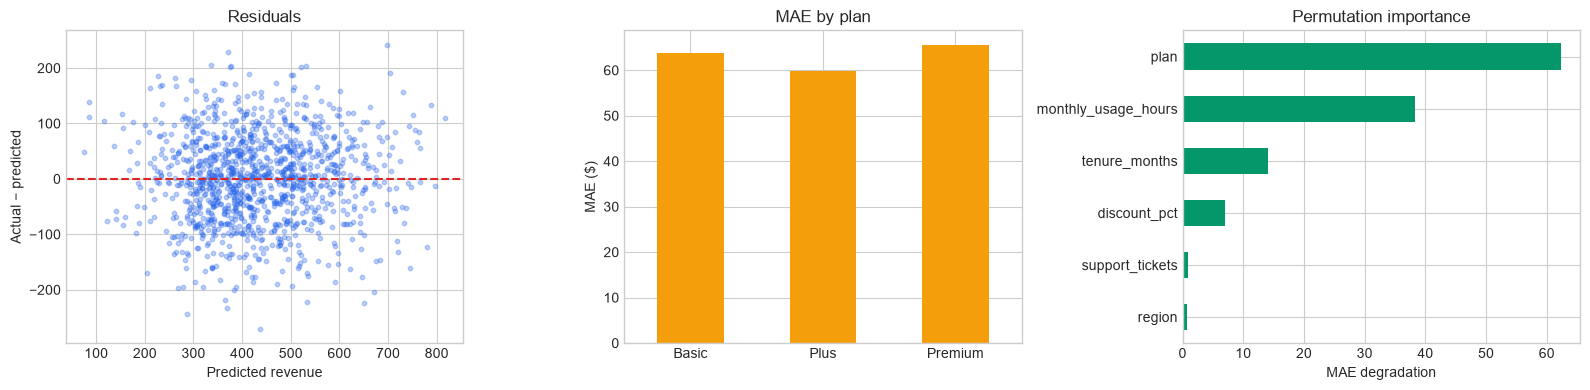

In [7]:
metrics=pd.DataFrame({"value":{"MAE":mean_absolute_error(y_test,pred),"RMSE":mean_squared_error(y_test,pred)**.5,"R-squared":r2_score(y_test,pred)}})
scored=X_test[["plan","region"]].copy(); scored["actual"]=y_test.to_numpy(); scored["prediction"]=pred; scored["absolute_error"]=np.abs(scored.actual-scored.prediction); scored["residual"]=scored.actual-scored.prediction
slices=scored.groupby("plan",observed=True).agg(customers=("actual","size"),mae=("absolute_error","mean"),bias=("residual","mean"))
pi=permutation_importance(search.best_estimator_,X_test,y_test,scoring="neg_mean_absolute_error",n_repeats=4,random_state=RANDOM_STATE,n_jobs=1)
importance=pd.DataFrame({"feature":X.columns,"importance":pi.importances_mean}).sort_values("importance",ascending=False)
display(metrics); display(slices); display(importance)
fig,axes=plt.subplots(1,3,figsize=(16,4)); axes[0].scatter(pred,y_test-pred,s=10,alpha=.3,color=COLORS[0]); axes[0].axhline(0,color=COLORS[3],ls="--"); axes[0].set(title="Residuals",xlabel="Predicted revenue",ylabel="Actual − predicted")
slices.mae.plot.bar(ax=axes[1],color=COLORS[2],rot=0); axes[1].set(title="MAE by plan",ylabel="MAE ($)",xlabel="")
importance.sort_values("importance").plot.barh(x="feature",y="importance",ax=axes[2],legend=False,color=COLORS[1]); axes[2].set(title="Permutation importance",xlabel="MAE degradation",ylabel=""); plt.tight_layout(); plt.show()

## 7. Package the model and define monitoring controls

,artifact,size_kb
0,model_metadata.json,0.350
1,revenue_regression_pipeline.joblib,"6,046.940"
2,sample_predictions.csv,4.269


,layer,measure,cadence
0,Input quality,Missingness/ranges/categories,Weekly
1,Prediction drift,Revenue forecast distribution,Weekly
2,Delayed performance,"MAE, RMSE, bias by plan",Monthly
3,Business impact,Incremental retained revenue,Experiment


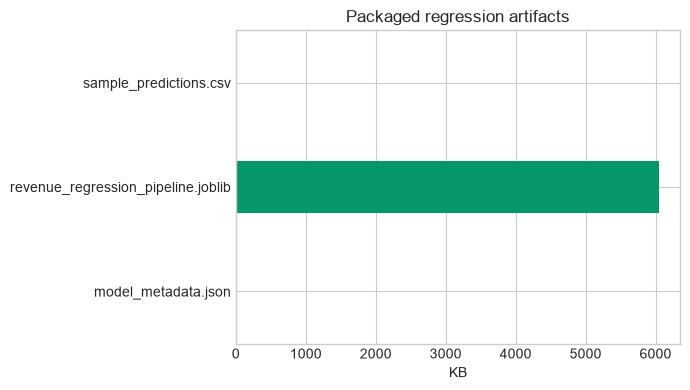

In [8]:
artifact_dir=Path("regression_artifacts"); artifact_dir.mkdir(exist_ok=True)
joblib.dump(search.best_estimator_,artifact_dir/"revenue_regression_pipeline.joblib")
meta={"target":"next_90d_revenue","primary_metric":"MAE","test_metrics":metrics.value.to_dict(),"features":list(X.columns),"random_state":RANDOM_STATE}
(artifact_dir/"model_metadata.json").write_text(json.dumps(meta,indent=2)); scored.head(50).to_csv(artifact_dir/"sample_predictions.csv",index=False)
manifest=pd.DataFrame([{"artifact":p.name,"size_kb":p.stat().st_size/1024} for p in artifact_dir.iterdir()])
controls=pd.DataFrame([("Input quality","Missingness/ranges/categories","Weekly"),("Prediction drift","Revenue forecast distribution","Weekly"),("Delayed performance","MAE, RMSE, bias by plan","Monthly"),("Business impact","Incremental retained revenue","Experiment")],columns=["layer","measure","cadence"])
display(manifest); display(controls)
ax=manifest.plot.barh(x="artifact",y="size_kb",legend=False,color=COLORS[1],figsize=(7,4)); ax.set(title="Packaged regression artifacts",xlabel="KB",ylabel=""); plt.tight_layout(); plt.show()

## Conclusion

Regression predicts a continuous magnitude. Success depends on a decision-relevant error metric, residual diagnostics, segment checks, and monitoring—not R² alone.